In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li, div.text_cell_render p{width:95% !important;font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
table td, th{font-size:16px;}
table{ margin-left:0 !important;   /* 왼쪽 여백 0 */}
</style>
"""))

<font size="5" color="red"><b>ch3. 분류분석</b></font>

# 1절. 분류분석 개요
    - 데이터 속성을 활용하여, 데이터에 대한 분류기준을 수립하는 과정. 타겟변수가 categorical인 분석
        ex. 고객등급예측, 휴면고객예측, 상품구매예측, 보험사기자예측....
    - sklearn 패키지
    - pip install scikit-learn
## 라이브러리의 데이터 셋의 접근
### load계열(패키지안에 데이터가 내장)
    - load_iris(), load_boston()...

### fetch 계열(패키지에 데이터가 없고, 인터넷연결하여 다운로드)
    - fetch_covtype() : 토지조사 데이터
    - fetch_20newgroups() : 뉴스텍스트 말뭉치....

### make 계열(새로운 데이터 셋 생성)
    - make_classification() : 분류분석용 가상의 데이터 생성
    - make_regression() : 회귀분석용 가상의 데이터 생성

In [3]:
# load계열(패키지내에 데이터가 있음)
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
# MNIST 데이터셋 로드
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


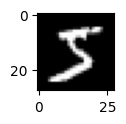

In [5]:
# 첫번째 숫자 이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X_train[0], cmap='gray')
plt.show()

In [8]:
# fetch계열(인터넷 연결후 다운로드 c:/Users/내컴퓨터명/scikit_learn_data/openml/ 다운)
from sklearn.datasets import fetch_openml
import numpy as np
# MNIST 다운로드
mnist = fetch_openml(name='mnist_784',
                    version=1, # 데이터버전
                    as_frame=False, # False는 넘파이배열
                    parser='auto') # 파싱 방식을 sklearn이 자동결정

In [14]:
X, y = mnist.data, mnist.target.astype(np.uint8) # y는 1byte짜리 양수int
print('원 X, y :', X.shape, y.shape)
X = X.reshape(70000, 28,28)
print('reshape후 X, y :', X.shape, y.shape)

원 X, y : (70000, 784) (70000,)
reshape후 X, y : (70000, 28, 28) (70000,)


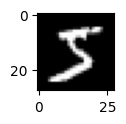

In [15]:
# 첫번째 숫자 이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X[0], cmap='gray')
plt.show()

# 2절. 분류분석의 종류
## 2.1 확률적 모형
- 주어진 데이터에 대해 각 클래스가 정답일 확률을 계산하는 모형
- **predict_proba() ; 각 분류 클래스가 될 확률들을 알려줌**(일부 판별함수모형에 있기는 함)
- **predict_log_proba() ; 확률의 로그값을 알려줌**

### 1) 확률적 생성모형
- 각 클래스별 특징 데이터의 확률분포를 추청한 다음 베이즈 정리를 사용하여 확률 계산. 소량의 데이터로도 작동하는 경우
```
    ex. sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis
        sklearn.naive_bayes.MultinomialNB
```

### 2) 확률적 판별모형
- 확률 함수를 추정하는 모형. 성능이 좋고, 해석이 쉬움
```
    ex. sklearn.linear_model.LogisticRegression
        sklearn.tree.DecisionTreeClassifier(의사결정나무) **분류에 영향을 주는 요인을 찾는데 더 많이 사용**
```

## 2.2 판별함수 모형
- 주어진 데이터를 클래스에 따라 서로 다른 영역으로 나누는 경계면을 찾은 후, 이 경계면으로부터 데이터가 어느 위치에 있는 계산하는 판별함수를 이용하는 모형
- **decision_function() : 어떤 클래스로 분류되었다를 알려줌**
```
    ex.sklearn.linear_model.Perceptron
       sklearn.svm.SVC
       sklearn.neural_network.MLPClassifier
```

=> RandomForest(배깅), XGboost, LGBM(부스팅), CatBoost등 앙상블 모형이 더 많이 사용됨

# 3절. 모형1. 확률적 생성 모형
- 베이즈 정리를 사용한 확률분포 계산
## 3.1 QDA(QuadraticDiscriminantAnalysis)
- 독립변수 X가 실수이고, 정규분포라고 가정(pdf 11p)

In [75]:
# 데이터
from sklearn.datasets import make_classification
X, y = make_classification(#n_samples=100, 데이터수(기본값)
                          n_features=2, # 독립변수 수
                          n_informative=2, # 독립변수 중 종속변수에 영향을 주는 변수 수
                          n_redundant=0,   # 독립변수끼리 선형관계가 있는 수(제외될 변수)
                          n_classes=2,     # 클래스 수
                          n_clusters_per_class=1, # 한 클래스당 군의 갯수
                          random_state=9,          # seed값
                          # weights=[0.5,0.5]
)
X.shape, y.shape

((100, 2), (100,))

In [76]:
# y.mean() : 0과 1 클래스가 5:5인지 확인
np.unique(y, return_counts=True)

(array([0, 1]), array([50, 50], dtype=int64))

In [77]:
# y가 0인 독립변수 X
X[y==0][:3]

array([[-0.73358502,  0.37658657],
       [-2.25158719,  3.59851363],
       [-0.6615633 ,  0.60245197]])

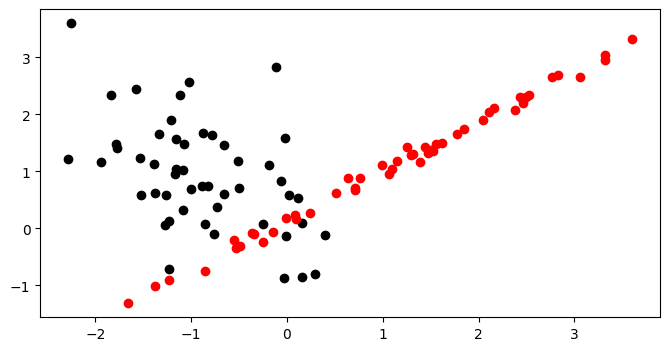

In [78]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4)
# y가 0인 독립변수
plt.scatter(X[y==0, 0], X[y==0, 1], c='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='r')
plt.show()

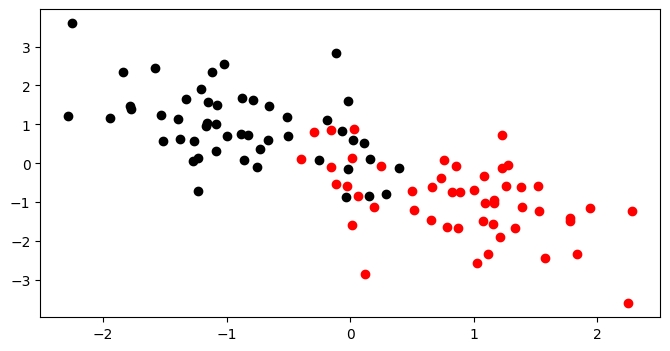

In [81]:
# 대칭구조를 만듦
X[y==1] = -X[y==0]
plt.scatter(X[y==0, 0], X[y==0, 1], c='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='r')
plt.show()

In [82]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
model = QuadraticDiscriminantAnalysis()
model.fit(X, y)

QuadraticDiscriminantAnalysis()

In [83]:
x = [[0, -1]] # 입력데이터 2차원
p = model.predict_proba(x) # 각 class가 될 확륙
print(p) # 확률 2차원

[[0.28449825 0.71550175]]


In [84]:
model.predict(x)

array([1])

In [85]:
x = [[0, 0]] # 입력데이터 2차원
p = model.predict_proba(x) # 각 class가 될 확륙
print(p) # 확률 2차원

[[0.5 0.5]]


In [86]:
model.predict(x)

array([0])

In [87]:
# 모델의 분류
model.classes_

array([0, 1])

In [88]:
# 교차표(혼동행렬)
import pandas as pd
y_hat = model.predict(X)
pd.crosstab(y, y_hat, colnames=['예측'], rownames=['실제'], margins=True)

예측,0,1,All
실제,,,
0,44,6,50
1,6,44,50
All,50,50,100


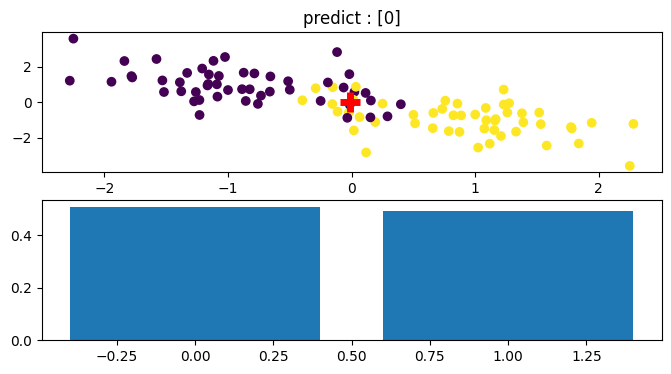

In [106]:
x = [[-0.01, 0]]
p = model.predict_proba(x)[0]
plt.subplot(211) # 2행1열로 subplot에서 첫번째 그래프
plt.scatter(x=X[:, 0], y=X[:, 1], c=y)
plt.scatter(x=x[0][0], y=x[0][1], c='r', s=200, marker='+', lw=5)
h = model.predict(x)
plt.title(f'predict : {h}')

plt.subplot(212)
plt.bar(model.classes_, p)
plt.show()

## 3-2 나이브베이지안 모형
- MultinomialNB

In [113]:
import seaborn as sns
iris = sns.load_dataset('iris')
# 학습데이터 : 넘파이배열
X = iris.iloc[:, :-1].to_numpy()
y = iris.iloc[:, -1].values
# 모형 생성 및 학습
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X, y)

MultinomialNB()

In [117]:
x = [[5.0, 3.6, 1.4, 0.2]]
h = model.predict(x) # 예측값
p = model.predict_proba(x) # 각 클래스별 확률
print('예측 :', h)
print(model.classes_)
print(p)

예측 : ['setosa']
['setosa' 'versicolor' 'virginica']
[[0.75925581 0.15640083 0.08434336]]


<BarContainer object of 3 artists>

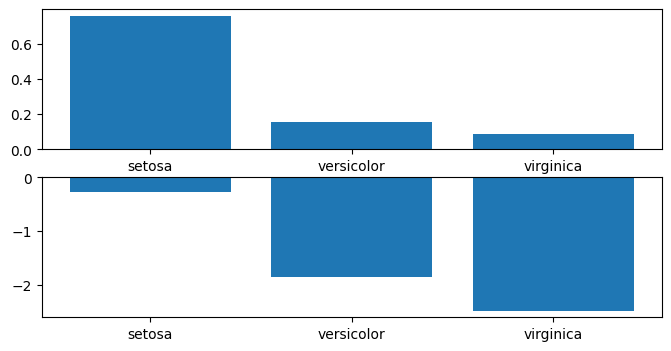

In [119]:
plt.subplot(2,1,1)
plt.bar(model.classes_, model.predict_proba(x)[0])
plt.subplot(2,1,2)
plt.bar(model.classes_, model.predict_log_proba(x)[0])

In [120]:
model.score(X, y) # 모델의 정확도

0.9533333333333334

# 4절. 모형2. 확률적 판별모형
## 4.1  로지스틱 회귀모형
- 종속변수가 0/1

In [123]:
# 가상의 데이터 셋
X, y = make_classification(n_samples=100, # 데이터 갯수(행수)
                          n_features=1,   # 독립변수 갯수 (기본값20)
                          n_redundant=0,  # 제외될 독립변수 갯수(기본값2)
                          n_informative=1, # 종속변수에 영향을 주는 독립변수 갯수(기본값2)
                          n_classes=2,    # 종속변수의 클래스 수
                          n_clusters_per_class=1,  # 클래스당 군의 갯수(기본값2)
                          random_state=1)
X.shape, y.shape

((100, 1), (100,))

In [129]:
np.c_[X, y][:3]

array([[-1.65902848,  0.        ],
       [-0.64202884,  0.        ],
       [-1.53918976,  0.        ]])

In [126]:
np.unique(y, return_counts=True)

(array([0, 1]), array([50, 50], dtype=int64))

In [127]:
# 모형
from sklearn.linear_model import LogisticRegression
model = LogisticRegression().fit(X, y)

In [147]:
# 모델 예측에 쓰일 x_data (2차원)
x_data = np.linspace(-3, 3, 100) # 1차원
# 2차원 데이터를 만들기 위한 축확장
x_data = x_data[:, np.newaxis]
# x_data = x_data.reshape(-1, 1)
# x_data = np.expand_dims(x_data, axis=1)
# x_data = x_data[:, None]
# x_data = np.array([[x] for x in x_data])
prob = model.predict_proba(x_data) # -3부터 3까지의 0일 확률과 1일 확률
prob[:3]

array([[9.99986168e-01, 1.38320570e-05],
       [9.99982885e-01, 1.71146738e-05],
       [9.99978824e-01, 2.11763030e-05]])

In [148]:
prob0 = prob[:, 0] # 0일 확률들
prob1 = prob[:, 1] # 1일 확률들

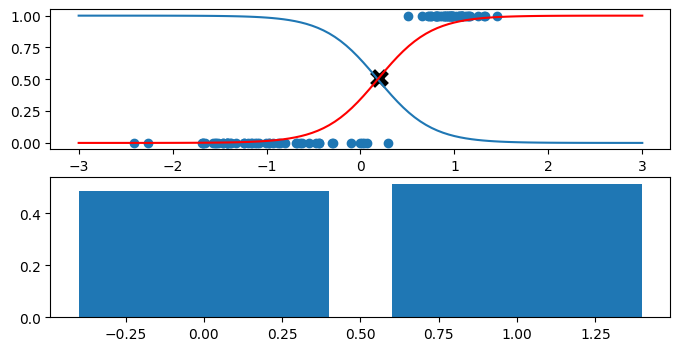

In [164]:
plt.subplot(2, 1, 1)
plt.scatter(X, y)
plt.plot(x_data, prob0)
plt.plot(x_data, prob1, c='r')

x = [[0.2]]
prob_x = model.predict_proba(x)[0]
plt.scatter(x[0], prob_x[1], marker='x', c='k', lw=5, s=100) # y값은 1일 확률

plt.subplot(2, 1, 2)
plt.bar(model.classes_, prob_x)
plt.show()

## 4-2 의사결정나무
- 여러가지 규칙을 순차적으로 적용하면서 독립변수 공간을 분할하는 분류모형
- **종속변수에 영향을 주는 독립변수의 범주를 찾는 목적**
- 의사결정나무 시각화 하기 위한 라이브러리 설치

In [181]:
from sklearn.datasets import load_iris
data = load_iris()
X = data.data[:, 2:] # petal_length, petal_width
y = data.target
feature_names = [name[:-5] for name in data.feature_names[2:]]
X.shape, y.shape, feature_names

((150, 2), (150,), ['petal length', 'petal width'])

In [182]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(criterion='entropy', # 트리의 분류품질기준을 entropy값으로
                                 max_depth=1,
                                 random_state=0)
dt_model.fit(X, y)

DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0)

In [191]:
x_data = [[6, 2.5]]
dt_model.predict(x_data)

array([1])

In [192]:
print(dt_model.predict_proba(x_data)[0])

[0.  0.5 0.5]


In [193]:
dt_model.score(X, y)

0.6666666666666666

In [198]:
dt_model5 = DecisionTreeClassifier(criterion='entropy',
                                  max_depth=5, # 최대 나무 깊이
                                  random_state=0)
dt_model5.fit(X, y)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

In [199]:
dt_model5.score(X,y)

0.9933333333333333

In [200]:
dt_model5.predict(x_data)

array([2])

In [201]:
dt_model5.predict_proba(x_data)

array([[0., 0., 1.]])